In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [224]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(
    "messy_IMDB_dataset.csv.xls",
    encoding="latin1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)

df.head()



,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,NaN,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,NaN,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,NaN,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,NaN,$ 222831817,1.780.147,"8,9f"


In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IMBD title ID   100 non-null    object 
 1   Original titlÊ  100 non-null    object 
 2   Release year    100 non-null    object 
 3   Genrë¨          100 non-null    object 
 4   Duration        99 non-null     object 
 5   Country         100 non-null    object 
 6   Content Rating  77 non-null     object 
 7   Director        100 non-null    object 
 8   Unnamed: 8      0 non-null      float64
 9   Income          100 non-null    object 
 10   Votes          100 non-null    object 
 11  Score           100 non-null    object 
dtypes: float64(1), object(11)
memory usage: 9.6+ KB


In [226]:
df.isna().sum()

IMBD title ID       1
Original titlÊ      1
Release year        1
Genrë¨              1
Duration            2
Country             1
Content Rating     24
Director            1
Unnamed: 8        101
Income              1
 Votes              1
Score               1
dtype: int64

In [227]:
df[df["IMBD title ID"].isna()]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [228]:
df=df.drop(13,axis=0)

In [229]:
df.isna().sum()

IMBD title ID       0
Original titlÊ      0
Release year        0
Genrë¨              0
Duration            1
Country             0
Content Rating     23
Director            0
Unnamed: 8        100
Income              0
 Votes              0
Score               0
dtype: int64

In [230]:
df[df["Duration"].isna()]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
14,tt0133093,The Matrix,1999-05-07,"Action, Sci-Fi",NaN,USA,R,"Lana Wachowski, Lilly Wachowski",NaN,$ 465718588,1.632.315,++8.7


In [231]:
df["Country"].value_counts()

Country
USA             62
UK              12
Italy            4
Japan            4
France           3
South Korea      2
Germany          2
New Zesland      1
New Zealand      1
New Zeland       1
US.              1
Brazil           1
US               1
Italy1           1
India            1
Denmark          1
West Germany     1
Iran             1
Name: count, dtype: int64

In [232]:
df[df["Country"] == "US."]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
24,tt0120689,The Green Mile,2000-10-03,"Crime, Drama, Fantasy",189,US.,R,Frank Darabont,NaN,$ 286801374,1.112.336,8.6


In [233]:
df[df["Country"] == "US"]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.


In [234]:
df.loc[24,"Country"] = "USA"

In [235]:
df.loc[2,"Country"] = "USA"

In [236]:
df["Country"].value_counts()

Country
USA             64
UK              12
Italy            4
Japan            4
France           3
South Korea      2
Germany          2
New Zealand      1
New Zesland      1
New Zeland       1
Brazil           1
Italy1           1
India            1
Denmark          1
West Germany     1
Iran             1
Name: count, dtype: int64

In [237]:
#df[df["Country"] == "New Zesland"] --11
df[df["Country"] == "New Zeland"]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
15,tt0167261,The Lord of the Rings: The Two Towers,01/16-03,"Action, Adventure, Drama",179,New Zeland,PG-13,Peter Jackson,NaN,$ 951227416,1.449.778,8.7.


In [240]:
df.loc[15,"Country"] = "New Zealand"

In [49]:
df[df["Country"] == "Italy1"]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score,USA_highlight
27,tt0118799,La vita B9 bella,1997-12-20,"Comedy, Drama, Romance",116.0,Italy1,NaN,Roberto Benigni,NaN,$ 230098753,605.648,8.6,Other


In [239]:
df.loc[27,"Country"] = "Italy"

In [243]:
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

In [244]:
df.groupby("Country")["Duration"].mean(numeric_only=True)

Country
Brazil          130.000000
Denmark         115.000000
France          114.666667
Germany         145.000000
India           170.000000
Iran            123.000000
Italy           145.800000
Japan           138.750000
New Zealand     190.000000
South Korea     126.000000
UK                     inf
USA             131.745763
West Germany    149.000000
Name: Duration, dtype: float64

In [245]:
df.isna().sum()

IMBD title ID       0
Original titlÊ      0
Release year        0
Genrë¨              0
Duration            6
Country             0
Content Rating     23
Director            0
Unnamed: 8        100
Income              0
 Votes              0
Score               0
dtype: int64

In [246]:
df=df.drop("Unnamed: 8",axis=1)

In [241]:
df


,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,NaN,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,NaN,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,USA,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,NaN,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,NaN,$ 222831817,1.780.147,"8,9f"
...,...,...,...,...,...,...,...,...,...,...,...,...
96,tt0070735,The Sting,1974-03-21,"Comedy, Crime, Drama",129,USA,PG,George Roy Hill,NaN,$ 156000000,236.285,7.5
97,tt0082096,Das Boot,1982-03-18,"Adventure, Drama, Thriller",149,West Germany,R,Wolfgang Petersen,NaN,$ 11487676,226.427,7.5
98,tt0059578,Per qualche dollaro in piÃ¹,1965-12-20,Western,132,Italy,NaN,Sergio Leone,NaN,$ 15000000,226.039,7.4
99,tt1832382,Jodaeiye Nader az Simin,2011-10-21,Drama,123,Iran,PG-13,Asghar Farhadi,NaN,$ 22926076,214.165,7.4


In [247]:
df[df["Duration"].isna()]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",NaN,USA,R,Quentin Tarantino,$ 222831817,1.780.147,"8,9f"
6,tt0108052,Schindler's List,1994-03-11,"Biography, Drama, History",NaN,USA,R,Steven Spielberg,$ 322287794,1.183.248,8.9
11,tt0120737,The Lord of the Rings: The Fellowship of the Ring,2002-01-18,"Action, Adventure, Drama",NaN,New Zealand,PG-13,Peter Jackson,$ 887934303,1.619.920,8.8
14,tt0133093,The Matrix,1999-05-07,"Action, Sci-Fi",NaN,USA,R,"Lana Wachowski, Lilly Wachowski",$ 465718588,1.632.315,++8.7
16,tt0080684,Star Wars: Episode V - The Empire Strikes Back,1980-09-19,"Action, Adventure, Fantasy",NaN,USA,PG,Irvin Kershner,$ 549265501,1.132.073,"8,7e-0"
18,tt0073486,One Flew Over the Cuckoo's Nest,18/11/1976,Drama,NaN,USA,R,Milos Forman,$ 108997629,891.071,8.7


In [248]:
filer= (df["Country"]=="USA") & (df["Duration"].isna())  
df.loc[filer, "Duration"] = 131

In [249]:
df[df["Duration"].isna()]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score
11,tt0120737,The Lord of the Rings: The Fellowship of the Ring,2002-01-18,"Action, Adventure, Drama",NaN,New Zealand,PG-13,Peter Jackson,$ 887934303,1.619.920,8.8


In [250]:

df["Duration"].fillna(190, inplace = True)

/var/folders/qy/0qtnbdzn1pb0vd98b2s698n40000gn/T/ipykernel_20216/2848259602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Duration"].fillna(190, inplace = True)


In [251]:
df[df["Duration"].isna()]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score


In [252]:
df["Content Rating"].value_counts()


Content Rating
R            45
PG-13        12
PG           11
G             6
Not Rated     1
Approved      1
Unrated       1
Name: count, dtype: int64

In [253]:
df["Content Rating"].value_counts()

Content Rating
R            45
PG-13        12
PG           11
G             6
Not Rated     1
Approved      1
Unrated       1
Name: count, dtype: int64

In [254]:
df[df["Content Rating"] == "Not Rated"]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score
7,tt0050083,12 Angry Men,1957-09-04,"Crime, Drama",96.0,USA,Not Rated,Sidney Lumet,$ 576,668.473,8.9


In [255]:
df.loc[7,"Content Rating"] = "Unrated"


<Axes: xlabel=' Votes '>

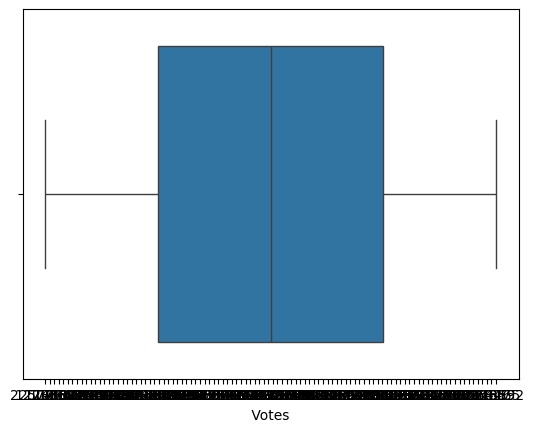

In [256]:
sns.boxplot(x=df[" Votes "])

In [197]:
print(df.columns.tolist())

['IMBD title ID', 'Original titlÊ', 'Release year', 'Genrë¨', 'Duration', 'Country', 'Content Rating', 'Director', 'Income', ' Votes ', 'Score']


In [204]:
'''num_cols = ["Income", " Votes ", "Score"]

for col in num_cols:
    # 1. Hamısını stringə çevir
    df[col] = df[col].astype(str)
    
    # 2. Vergül, dollar işarəsi və boşluqları sil
    df[col] = df[col].str.replace(",", "")
    df[col] = df[col].str.replace(".", "") if col != "Score" else df[col]  # Score üçün nöqtəni saxla
    df[col] = df[col].str.replace("$", "")
    df[col] = df[col].str.strip()
    
    # 3. Numeric çevirmək
    df[col] = pd.to_numeric(df[col], errors="coerce")'''


<Axes: xlabel=' Votes '>

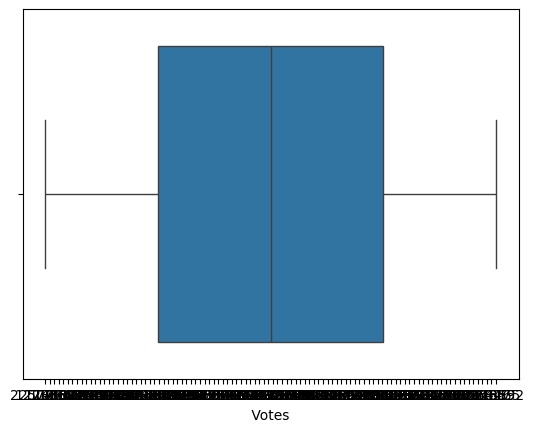

In [257]:
sns.boxplot(x=df[" Votes "])

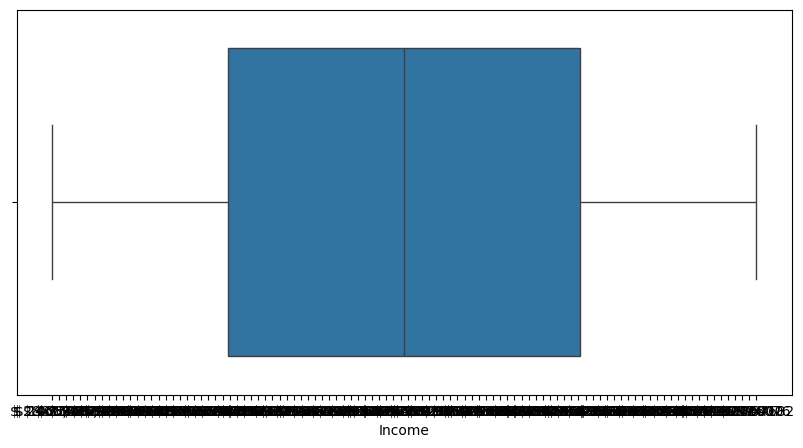

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5)) 
sns.boxplot(x=df["Income"])
plt.show()

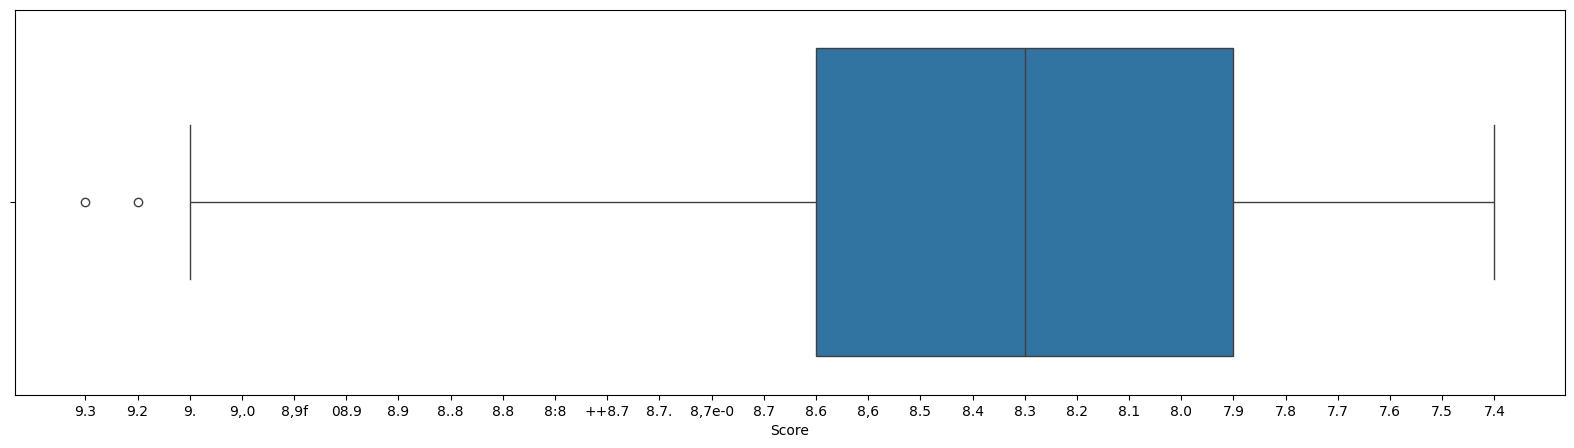

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5)) 
sns.boxplot(x=df["Score"])
plt.show()

<Axes: xlabel='Duration'>

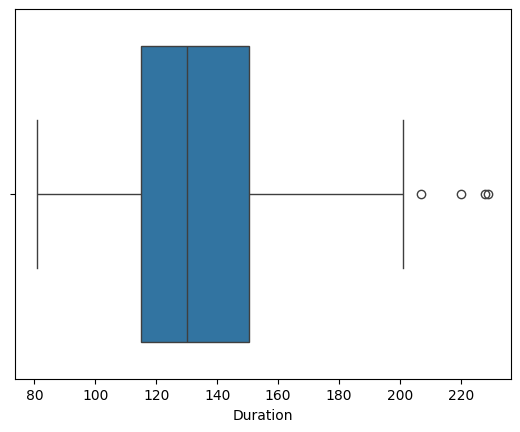

In [260]:
sns.boxplot(x=df["Duration"]) ##nomraldir oal biler


In [261]:
df["Score"]

0       9.3
1       9.2
2        9.
3      9,.0
4      8,9f
       ... 
96      7.5
97      7.5
98      7.4
99      7.4
100     7.4
Name: Score, Length: 100, dtype: object

In [281]:
df.describe()

,Duration
count,76.000000
mean,138.105263
std,32.588169
min,81.000000
25%,115.750000
50%,131.000000
75%,153.500000
max,229.000000


<Axes: xlabel='Duration'>

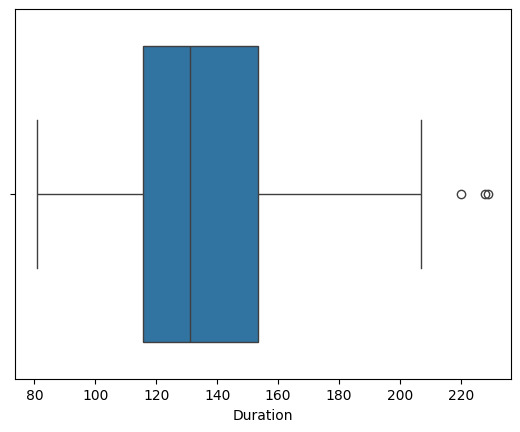

In [280]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)  # əvvəlcə inf → NaN
df.dropna(inplace=True)  # sonra NaN olan sətirləri sil

sns.boxplot(x=df["Duration"]) ##nomraldir oal biler

In [282]:
df.describe() #inf olani sildim bu noramldri

,Duration
count,76.000000
mean,138.105263
std,32.588169
min,81.000000
25%,115.750000
50%,131.000000
75%,153.500000
max,229.000000


In [284]:
df[df["Duration"] ==229]

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score
68,tt0087843,Once Upon a Time in America,1984-09-28,"Crime, Drama",229.0,USA,R,Sergio Leone,$ 5472914,302.317,8.0


In [285]:
df = df.drop(68 , axis = 0)

<Axes: xlabel='Duration'>

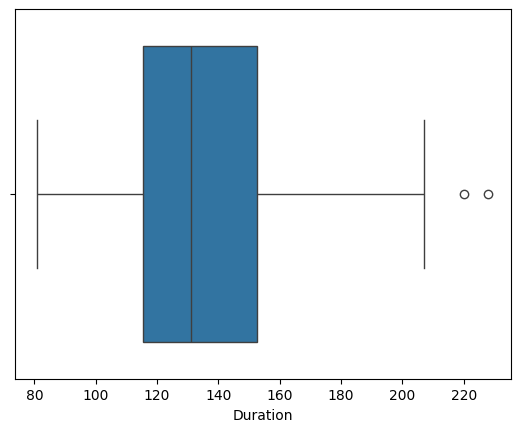

In [286]:
sns.boxplot(x=df["Duration"])